# Resnet-50

In [ ]:
import os
import subprocess
import sys

# Suppress outputs for pip install
subprocess.run(["pip", "install", "configilm"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run(["pip", "install", "lightning"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run(["pip", "install", "lmdb"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Suppress output for git clone
subprocess.run(["git", "clone", "https://git.tu-berlin.de/rsim/reben-training-scripts.git"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Change directory without output
# os.chdir('/content/reben-training-scripts')
# from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier
sys.path.append('/content/reben-training-scripts')


In [ ]:
!pip uninstall -y tensorflow
!pip install tensorflow-cpu

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.6 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.image import resize
from tqdm import tqdm

import json
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, LambdaLR
from torch.cuda.amp import GradScaler, autocast
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import classification_report

from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier
from configilm.extra.BENv2_utils import band_combi_to_mean_std, STANDARD_BANDS

### Initialize the Preprocessor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/My Drive/EuroSAT')


In [ ]:
from configilm.extra.BENv2_utils import band_combi_to_mean_std, STANDARD_BANDS
from preprocessing import EuroSATPreprocessor, TensorflowToTorchDataset

# Get mean and std for normalization
means, stds = band_combi_to_mean_std(STANDARD_BANDS[10], interpolation="120_nearest")

# Initialize the preprocessor
preprocessor = EuroSATPreprocessor(input_size=120, band_indices=[1, 2, 3, 4, 5, 6, 7, 8, 10, 11], means=means, stds=stds)


In [ ]:
# Save the dataset to a specific directory
save_path = '/content/eurosat_dataset'
dataset, info = tfds.load("eurosat/all", split='train', with_info=True, data_dir=save_path)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/27000 [00:00<?, ? examples/s]

Shuffling /content/eurosat_dataset/eurosat/all/incomplete.EAEF1A_2.0.0/eurosat-train.tfrecord*...:   0%|      …

Dataset eurosat downloaded and prepared to /content/eurosat_dataset/eurosat/all/2.0.0. Subsequent calls will reuse this data.


In [ ]:
# Inspect dataset labels
for sample in dataset.take(5):  # Inspect 5 samples
    label = sample['label']
    print("Label Type:", type(label.numpy()))
    print("Label Shape:", label.shape)
    print("Label Value:", label.numpy())
    print("-" * 30)


Label Type: <class 'numpy.int64'>
Label Shape: ()
Label Value: 8
------------------------------
Label Type: <class 'numpy.int64'>
Label Shape: ()
Label Value: 4
------------------------------
Label Type: <class 'numpy.int64'>
Label Shape: ()
Label Value: 5
------------------------------
Label Type: <class 'numpy.int64'>
Label Shape: ()
Label Value: 5
------------------------------
Label Type: <class 'numpy.int64'>
Label Shape: ()
Label Value: 3
------------------------------


EuroSAT dataset is multi class

In [ ]:
# Apply preprocessing using map
def preprocess_sample(sample):
    """Preprocess a single sample using the EuroSATPreprocessor."""
    return preprocessor.preprocess_sample(sample)

# Preprocess the entire dataset
preprocessed_dataset = dataset.map(preprocess_sample, num_parallel_calls=tf.data.AUTOTUNE)

# Check a preprocessed sample
for sample in preprocessed_dataset.take(1):
    print("Filename:", sample['filename'].numpy())
    print("Image Shape:", sample['sentinel2'].shape)
    print("Label:", sample['label'].numpy())

Filename: b'River_15.tif'
Image Shape: (120, 120, 10)
Label: 8


In [ ]:
# Convert TensorFlow dataset to PyTorch dataset
torch_dataset = TensorflowToTorchDataset(preprocessed_dataset)

# Calculate dataset sizes for train, validation, and test splits
dataset_size = len(torch_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size  # Ensures no data is left out

# Set the random seed for reproducibility
torch.manual_seed(42)

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(torch_dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Check a batch from the train_loader
for images, labels in train_loader:
    print("Batch Image Shape:", images.shape)  # [batch_size, channels, height, width]
    print("Batch Label Shape:", labels.shape)  # [batch_size]
    break


Batch Image Shape: torch.Size([64, 10, 120, 120])
Batch Label Shape: torch.Size([64])


In [ ]:
for _, labels in train_loader:
    print("Label Shape:", labels.shape)
    print("Sample Label:", labels[0])
    break


Label Shape: torch.Size([64])
Sample Label: tensor(1)


In [ ]:
for images, labels in train_loader:
    print(f"Image Shape: {images.shape}")  # [batch_size, channels, height, width]
    print(f"Label Shape: {labels.shape}")  # [batch_size]
    print(f"Sample Labels: {labels[:5]}")
    break


Image Shape: torch.Size([64, 10, 120, 120])
Label Shape: torch.Size([64])
Sample Labels: tensor([7, 1, 8, 5, 8])


## Load the BigEarthNet pre trained model

In [ ]:
from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier

model_resnet_50 = BigEarthNetv2_0_ImageClassifier.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet50-s2-v0.1.1")
model_resnet_101 = BigEarthNetv2_0_ImageClassifier.from_pretrained(
  "BIFOLD-BigEarthNetv2-0/resnet101-s2-v0.1.1")


In [ ]:
model_vit = BigEarthNetv2_0_ImageClassifier.from_pretrained(
  "BIFOLD-BigEarthNetv2-0/vit_base_patch8_224-s2-v0.1.1")

In [ ]:
model_mixer = BigEarthNetv2_0_ImageClassifier.from_pretrained(
  "BIFOLD-BigEarthNetv2-0/mixer_b16_224-s2-v0.1.1")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/237M [00:00<?, ?B/s]

In [ ]:
print(model_mixer)

BigEarthNetv2_0_ImageClassifier(
  (model): ConfigILM(
    (vision_encoder): MlpMixer(
      (stem): PatchEmbed(
        (proj): Conv2d(10, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (blocks): Sequential(
        (0): MixerBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp_tokens): Mlp(
            (fc1): Linear(in_features=49, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=49, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (drop_path): DropPath(drop_prob=0.150)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp_channels): Mlp(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (drop1): Drop

In [ ]:
def modify_mlp_mixer_model(model, num_classes=10, unfreeze_last_n=1):
    """
    Modifies the MLP-Mixer model:
    1. Freezes all layers in the vision_encoder except the last `unfreeze_last_n` layers.
    2. Updates the final fully connected layer to match the specified number of classes.

    Args:
        model (torch.nn.Module): The MLP-Mixer model (BigEarthNetv2_0_ImageClassifier).
        num_classes (int): The number of output classes for the new dataset.
        unfreeze_last_n (int): The number of layers to unfreeze in the vision_encoder.

    Returns:
        torch.nn.Module: The modified model.
    """
    # Access the vision_encoder (MLP-Mixer) inside the model
    vision_encoder = model.model.vision_encoder

    # Freeze all layers by default
    for param in vision_encoder.parameters():
        param.requires_grad = False

    # Get all MixerBlocks in the vision_encoder
    mixer_blocks = vision_encoder.blocks
    total_blocks = len(mixer_blocks)

    # Unfreeze the last `unfreeze_last_n` blocks
    for i in range(total_blocks - unfreeze_last_n, total_blocks):
        for param in mixer_blocks[i].parameters():
            param.requires_grad = True

    # Replace the final classification head
    in_features = vision_encoder.head.in_features
    new_head = nn.Linear(in_features, num_classes)

    # Initialize the new classification head
    nn.init.xavier_uniform_(new_head.weight)
    if new_head.bias is not None:
        nn.init.constant_(new_head.bias, 0)

    # Move the new head to the same device as the model's parameters
    device = next(model.parameters()).device
    new_head = new_head.to(device)

    # Replace the old head with the new one
    vision_encoder.head = new_head

    # Ensure the new head's parameters are trainable
    for param in vision_encoder.head.parameters():
        param.requires_grad = True

    print(f"Updated the classification head to {num_classes} classes and unfroze the last {unfreeze_last_n} blocks.")
    return model

In [ ]:
def modify_vit_model_dynamic(model, num_classes=10, unfreeze_last_n=1):
    """
    Modifies the Vision Transformer (ViT) model:
    1. Freezes all layers in the `blocks` except the last `unfreeze_last_n` layers.
    2. Updates the final classification head to match the specified number of classes.

    Args:
        model (torch.nn.Module): The Vision Transformer model.
        num_classes (int): The number of output classes for the new dataset.
        unfreeze_last_n (int): The number of layers (blocks) to unfreeze in the vision encoder.

    Returns:
        torch.nn.Module: The modified model.
    """
    # Access the vision encoder (ViT) blocks
    vit_blocks = model.model.vision_encoder.blocks
    total_blocks = len(vit_blocks)

    # Freeze all layers by default
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last `unfreeze_last_n` blocks
    for i in range(total_blocks - unfreeze_last_n, total_blocks):
        for param in vit_blocks[i].parameters():
            param.requires_grad = True

    # Update the final classification head
    in_features = model.model.vision_encoder.head.in_features
    new_head = nn.Linear(in_features, num_classes)

    # Initialize the new classification head
    nn.init.xavier_uniform_(new_head.weight)
    if new_head.bias is not None:
        nn.init.constant_(new_head.bias, 0)

    # Move the new head to the same device as the model's parameters
    device = next(model.parameters()).device
    new_head = new_head.to(device)

    # Replace the old head with the new one
    model.model.vision_encoder.head = new_head

    # Ensure the new head's parameters are trainable
    for param in model.model.vision_encoder.head.parameters():
        param.requires_grad = True

    print(f"Unfroze the last {unfreeze_last_n} blocks and updated the classification head to {num_classes} classes.")

    return model


In [ ]:
def modify_bigearthnet_model_dynamic(model, num_classes=10, unfreeze_last_n=1):
    """
    Modifies the BigEarthNetv2_0_ImageClassifier model:
    1. Freezes all layers in the vision_encoder except the last `unfreeze_last_n` layers.
    2. Updates the final fully connected layer to match the specified number of classes.

    Args:
        model (torch.nn.Module): The BigEarthNetv2_0_ImageClassifier model.
        num_classes (int): The number of output classes for the new dataset.
        unfreeze_last_n (int): The number of layers to unfreeze in the vision_encoder.

    Returns:
        torch.nn.Module: The modified model.
    """
    # Access the vision_encoder (ResNet) inside the model
    vision_encoder = model.model.vision_encoder

    # Freeze all layers by default
    for param in vision_encoder.parameters():
        param.requires_grad = False

    # Get all named children (layers) of the vision_encoder
    children = list(vision_encoder.named_children())
    total_layers = len(children)

    # Unfreeze the last `unfreeze_last_n` layers
    for name, layer in children[-unfreeze_last_n:]:
        for param in layer.parameters():
            param.requires_grad = True

    # Replace the final fully connected (fc) layer
    num_ftrs = vision_encoder.fc.in_features
    vision_encoder.fc = nn.Linear(num_ftrs, num_classes)

    # Reassign the modified vision_encoder back to the model
    model.model.vision_encoder = vision_encoder

    return model


In [ ]:
print(model_vit)

None


In [ ]:
def print_layer_status(model):
    """
    Prints each layer in the model and whether it is frozen (requires_grad=False) or not.

    Args:
        model (torch.nn.Module): The model to inspect.
    """
    print("Layer Name", "\t", "Requires Grad")
    print("-" * 30)
    for name, param in model.named_parameters():
        print(f"{name:40} \t {param.requires_grad}")



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time

def train_model(model, train_loader, val_loader, num_epochs, learning_rate, weight_decay, device,
                log_interval=10, classes=None):
    """
    Function to train and validate the model with customizable hyperparameters and visualizations.

    Args:
        model (torch.nn.Module): The modified ResNet model.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        num_epochs (int): Number of training epochs.
        learning_rate (float): Learning rate for the optimizer.
        weight_decay (float): Weight decay (L2 regularization).
        device (torch.device): Device to run the training on.
        log_interval (int, optional): Interval to log batch-level training stats. Default is 10.
        classes (list, optional): List of class names for plotting confusion matrix. Default is None.

    Returns:
        model: Trained model.
    """
    # Initialize lists for metrics
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Move model to the specified device
    model = model.to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=learning_rate, weight_decay=weight_decay)

    # Learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

    # Best validation loss for saving the model
    best_val_loss = float("inf")

    # Training loop
    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        start_time = time.time()

        # Training phase
        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")):
            # Move images and labels to the specified device
            images, labels = images.to(device), labels.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels.long())  # CrossEntropyLoss expects long tensor for labels

            # Backward pass
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Update running loss and accuracy
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

        # Compute average training loss and accuracy
        avg_train_loss = running_loss / len(train_loader)
        avg_train_acc = (running_acc / len(train_loader)) * 100
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels.long())
                val_loss += loss.item()
                val_acc += calculate_accuracy(outputs, labels)

        # Compute average validation loss and accuracy
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = (val_acc / len(val_loader)) * 100
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_acc)
        epoch_time = time.time() - start_time

        # Adjust learning rate using the scheduler
        lr_scheduler.step(avg_val_loss)

        # Log learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # Log epoch stats
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}% | "
              f"LR: {current_lr:.6f} | Time: {epoch_time:.2f}s")

        # Save the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved!")

    print("Training complete!")

    # Plot metrics
    plot_training_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

    # Plot confusion matrix if classes are provided
    if classes:
        print("Generating Confusion Matrix...")
        plot_confusion_matrix(model, val_loader, classes, device)

    return model


In [ ]:
def calculate_accuracy(outputs, labels):
    """
    Calculates the accuracy of predictions.

    Args:
        outputs (torch.Tensor): Model predictions (logits).
        labels (torch.Tensor): Ground truth labels.

    Returns:
        float: Accuracy as a proportion.
    """
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [ ]:
def calculate_accuracy_with_loader(model, data_loader, device):
    """
    Calculates the accuracy of the model using a DataLoader.

    Args:
        model (torch.nn.Module): Trained model.
        data_loader (DataLoader): DataLoader containing the test data.
        device (torch.device): Device to run the calculations on.

    Returns:
        float: Overall accuracy as a percentage.
    """
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return (correct / total) * 100

In [ ]:
# ===========================
# Hyperparameters and Setup
# ===========================
num_epochs = 30          # Number of training epochs
batch_size = 64          # Batch size
learning_rate = 1e-4     # Learning rate
weight_decay = 1e-5      # Weight decay (L2 regularization)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# Load Data and Model
# ===========================
# Assuming the dataset splits are ready
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Load and modify the model
num_classes = 10
freeze_layers = 3

# model_resnet_50 = modify_bigearthnet_model_dynamic(model_resnet_50, num_classes=num_classes, unfreeze_last_n=freeze_layers)

# model_resnet_101 = modify_bigearthnet_model_dynamic(model_resnet_101, num_classes=num_classes, unfreeze_last_n=freeze_layers)

# model_vit = modify_vit_model_dynamic(model_vit, num_classes=num_classes, unfreeze_last_n=freeze_layers)

model_mixer = modify_mlp_mixer_model(model_mixer, num_classes=num_classes, unfreeze_last_n=freeze_layers)

# Example usage:
# print_layer_status(model_resnet_50)
# print("-" * 30)
# print_layer_status(model_resnet_101)

Updated the classification head to 10 classes and unfroze the last 3 blocks.


In [ ]:
print(model_mixer)

BigEarthNetv2_0_ImageClassifier(
  (model): ConfigILM(
    (vision_encoder): MlpMixer(
      (stem): PatchEmbed(
        (proj): Conv2d(10, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (blocks): Sequential(
        (0): MixerBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp_tokens): Mlp(
            (fc1): Linear(in_features=49, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=49, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (drop_path): DropPath(drop_prob=0.150)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp_channels): Mlp(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (drop1): Drop

Epoch 1/30 - Training: 100%|██████████| 296/296 [00:38<00:00,  7.75it/s]


Epoch [1/30] | Train Loss: 0.8266 | Train Acc: 72.69% | Val Loss: 0.3730 | Val Acc: 87.70% | LR: 0.000100 | Time: 44.01s
Best model saved!


Epoch 2/30 - Training: 100%|██████████| 296/296 [00:37<00:00,  7.83it/s]


Epoch [2/30] | Train Loss: 0.4685 | Train Acc: 84.35% | Val Loss: 0.3040 | Val Acc: 89.79% | LR: 0.000100 | Time: 43.61s
Best model saved!


Epoch 3/30 - Training: 100%|██████████| 296/296 [00:38<00:00,  7.78it/s]


...

Epoch [28/30] | Train Loss: 0.1962 | Train Acc: 93.36% | Val Loss: 0.2203 | Val Acc: 92.96% | LR: 0.000000 | Time: 44.18s


Epoch 29/30 - Training: 100%|██████████| 296/296 [00:37<00:00,  7.82it/s]


Epoch [29/30] | Train Loss: 0.1953 | Train Acc: 93.50% | Val Loss: 0.2204 | Val Acc: 92.96% | LR: 0.000000 | Time: 43.66s


Epoch 30/30 - Training: 100%|██████████| 296/296 [00:38<00:00,  7.77it/s]


Epoch [30/30] | Train Loss: 0.1972 | Train Acc: 93.41% | Val Loss: 0.2203 | Val Acc: 92.96% | LR: 0.000000 | Time: 43.92s
Training complete!


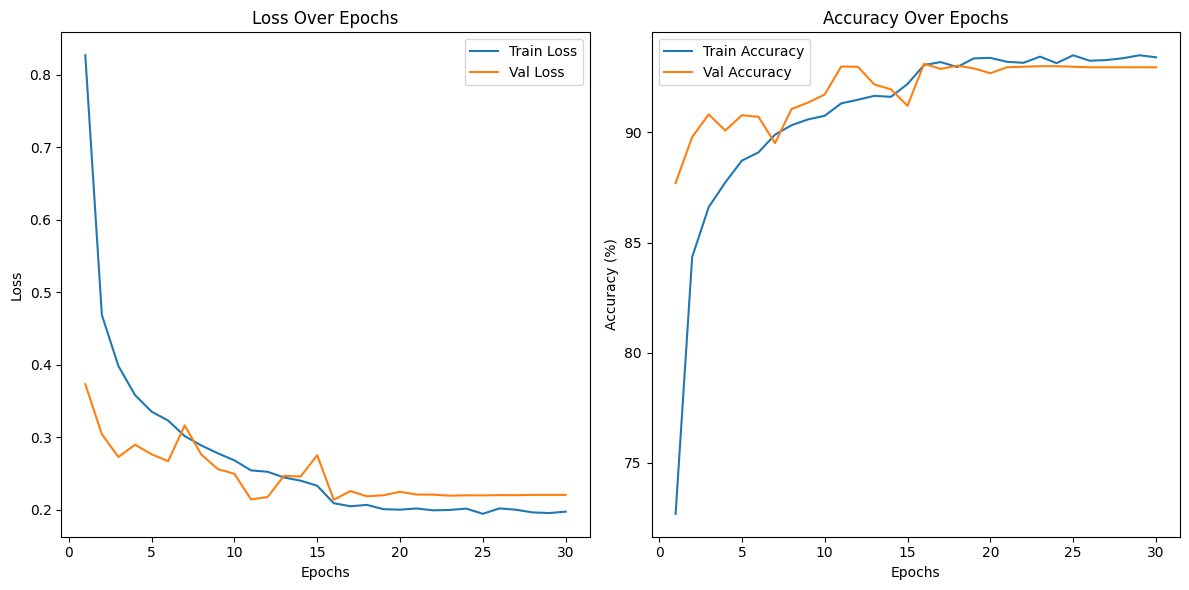

<ipython-input-68-d11a154cc892>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_mixer.load_state_dict(torch.load("best_model.pth"))


Best model loaded for evaluation!


In [ ]:
# ===========================
# Train the Model | MLP Mixer
# ===========================
trained_model_mixer = train_model(model_mixer, train_loader, val_loader, num_epochs, learning_rate, weight_decay, device)

# Load the best model
model_mixer.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded for evaluation!")

Epoch 1/20 - Training: 100%|██████████| 296/296 [02:20<00:00,  2.11it/s]


Epoch [1/20] | Train Loss: 0.4320 | Train Acc: 85.41% | Val Loss: 0.4240 | Val Acc: 85.83% | LR: 0.000100 | Time: 163.53s
Best model saved!


Epoch 2/20 - Training: 100%|██████████| 296/296 [02:20<00:00,  2.11it/s]


Epoch [2/20] | Train Loss: 0.4138 | Train Acc: 85.87% | Val Loss: 0.3958 | Val Acc: 86.40% | LR: 0.000100 | Time: 163.40s
Best model saved!


Epoch 3/20 - Training: 100%|██████████| 296/296 [02:20<00:00,  2.11it/s]


...

Epoch [18/20] | Train Loss: 0.2870 | Train Acc: 89.95% | Val Loss: 0.3343 | Val Acc: 88.89% | LR: 0.000100 | Time: 163.17s


Epoch 19/20 - Training: 100%|██████████| 296/296 [02:19<00:00,  2.12it/s]


Epoch [19/20] | Train Loss: 0.2780 | Train Acc: 90.42% | Val Loss: 0.3316 | Val Acc: 88.96% | LR: 0.000100 | Time: 163.18s


Epoch 20/20 - Training: 100%|██████████| 296/296 [02:19<00:00,  2.12it/s]


Epoch [20/20] | Train Loss: 0.2741 | Train Acc: 90.41% | Val Loss: 0.3217 | Val Acc: 89.13% | LR: 0.000100 | Time: 163.17s
Best model saved!
Training complete!


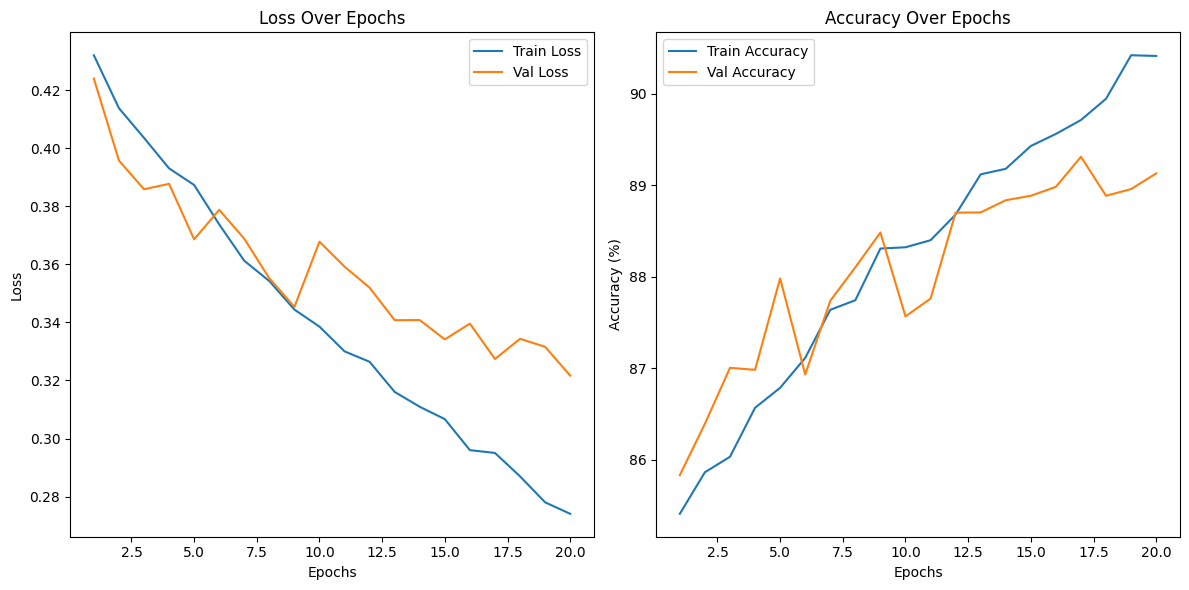

Best model loaded for evaluation!


<ipython-input-57-803f970c82d8>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_vit.load_state_dict(torch.load("best_model.pth"))


In [ ]:
# ===========================
# Train the Model | ViT
# ===========================
trained_model_vit = train_model(model_vit, train_loader, val_loader, num_epochs, learning_rate, weight_decay, device)

# Load the best model
model_vit.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded for evaluation!")

Epoch 1/20 - Training: 100%|██████████| 296/296 [00:15<00:00, 19.19it/s]


Epoch [1/20] | Train Loss: 0.7139 | Train Acc: 91.39% | Val Loss: 0.2338 | Val Acc: 95.52% | LR: 0.000100 | Time: 18.12s
Best model saved!


Epoch 2/20 - Training: 100%|██████████| 296/296 [00:14<00:00, 19.74it/s]


Epoch [2/20] | Train Loss: 0.1954 | Train Acc: 96.99% | Val Loss: 0.1512 | Val Acc: 95.93% | LR: 0.000100 | Time: 17.67s
Best model saved!


Epoch 3/20 - Training: 100%|██████████| 296/296 [00:15<00:00, 19.44it/s]


...

Epoch [18/20] | Train Loss: 0.0693 | Train Acc: 97.70% | Val Loss: 0.1264 | Val Acc: 96.10% | LR: 0.000100 | Time: 17.92s


Epoch 19/20 - Training: 100%|██████████| 296/296 [00:14<00:00, 19.81it/s]


Epoch [19/20] | Train Loss: 0.0730 | Train Acc: 97.58% | Val Loss: 0.1285 | Val Acc: 96.01% | LR: 0.000100 | Time: 17.58s


Epoch 20/20 - Training: 100%|██████████| 296/296 [00:15<00:00, 19.43it/s]


Epoch [20/20] | Train Loss: 0.0695 | Train Acc: 97.68% | Val Loss: 0.1314 | Val Acc: 95.88% | LR: 0.000100 | Time: 17.90s
Training complete!


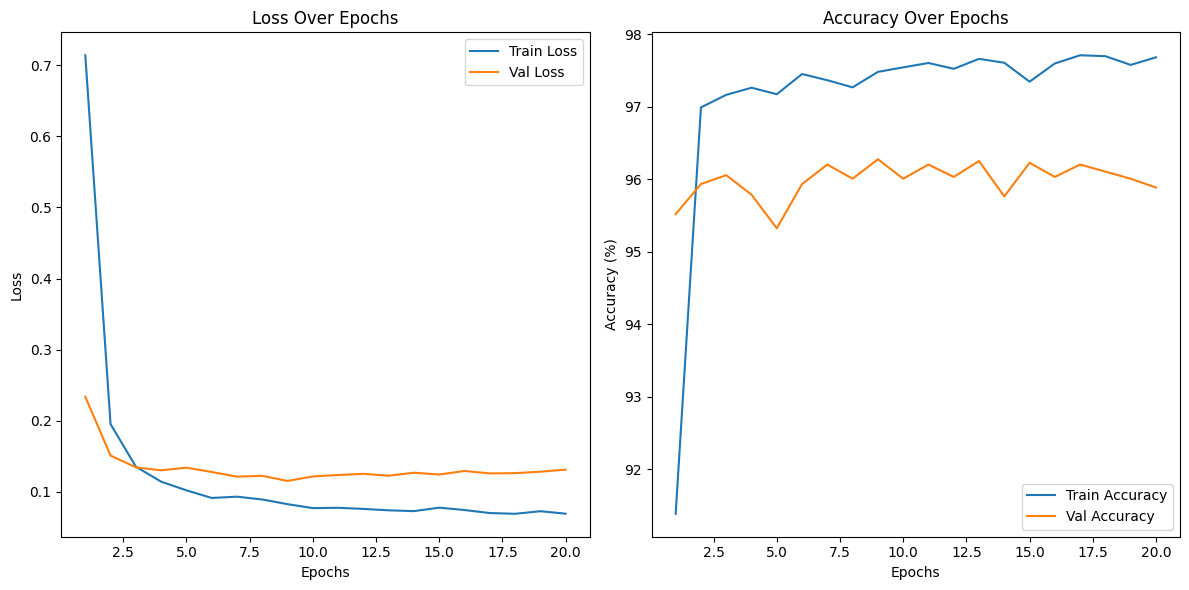

Best model loaded for evaluation!


<ipython-input-99-2971f890a99b>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet_50.load_state_dict(torch.load("best_model.pth"))


In [ ]:
# ===========================
# Train the Model | ResNet-50
# ===========================
trained_model_resnet_50 = train_model(model_resnet_50, train_loader, val_loader, num_epochs, learning_rate, weight_decay, device)

# Load the best model
model_resnet_50.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded for evaluation!")

In [ ]:
calculate_accuracy_with_loader(model_resnet_50, test_loader, device)

96.14814814814815

Epoch 1/20 - Training: 100%|██████████| 296/296 [00:18<00:00, 15.73it/s]


Epoch [1/20] | Train Loss: 0.6882 | Train Acc: 90.13% | Val Loss: 0.2412 | Val Acc: 94.74% | LR: 0.000100 | Time: 22.17s
Best model saved!


Epoch 2/20 - Training: 100%|██████████| 296/296 [00:18<00:00, 15.95it/s]


Epoch [2/20] | Train Loss: 0.1990 | Train Acc: 96.07% | Val Loss: 0.1683 | Val Acc: 95.25% | LR: 0.000100 | Time: 21.90s
Best model saved!


Epoch 3/20 - Training: 100%|██████████| 296/296 [00:18<00:00, 15.93it/s]


...

Epoch [18/20] | Train Loss: 0.0815 | Train Acc: 97.24% | Val Loss: 0.1318 | Val Acc: 95.96% | LR: 0.000100 | Time: 21.98s


Epoch 19/20 - Training: 100%|██████████| 296/296 [00:18<00:00, 15.81it/s]


Epoch [19/20] | Train Loss: 0.0811 | Train Acc: 97.37% | Val Loss: 0.1294 | Val Acc: 95.84% | LR: 0.000100 | Time: 22.20s


Epoch 20/20 - Training: 100%|██████████| 296/296 [00:18<00:00, 16.03it/s]


Epoch [20/20] | Train Loss: 0.0789 | Train Acc: 97.35% | Val Loss: 0.1295 | Val Acc: 95.96% | LR: 0.000100 | Time: 21.82s
Training complete!


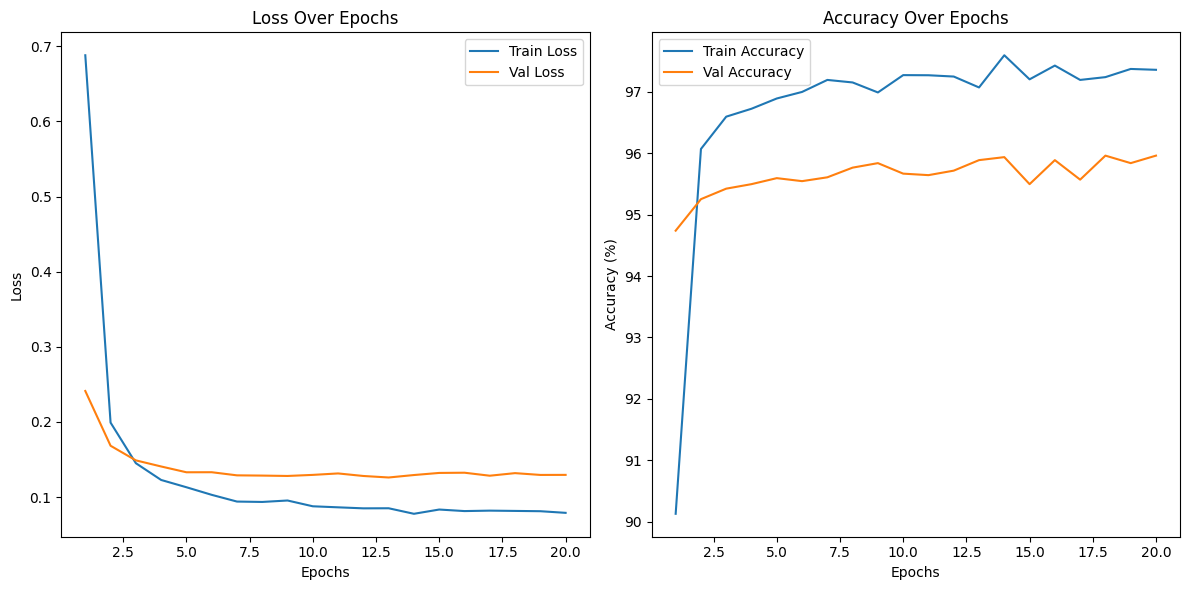

<ipython-input-101-57ac26f153d3>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet_101.load_state_dict(torch.load("best_model.pth"))


Best model loaded for evaluation!


In [ ]:
# ===========================
# Train the Model
# ===========================
trained_model_resnet_101 = train_model(model_resnet_101, train_loader, val_loader, num_epochs, learning_rate, weight_decay, device)

# Load the best model
model_resnet_101.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded for evaluation!")

In [ ]:
calculate_accuracy_with_loader(model_resnet_101, test_loader, device)

95.9753086419753

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

def evaluate_model(model, data_loader, device, classes=None):
    """
    Evaluates the model on a given dataset and calculates F1 score, accuracy, precision, recall, and more.

    Args:
        model (torch.nn.Module): Trained PyTorch model.
        data_loader (DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): Device to perform evaluation on.
        classes (list, optional): List of class names for better readability in metrics. Default is None.

    Returns:
        dict: Dictionary containing calculated metrics (accuracy, precision, recall, F1 score).
    """
    # Set the model to evaluation mode
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Append predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    conf_matrix = confusion_matrix(all_labels, all_preds)

    # Print metrics
    print("=== Evaluation Results ===")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes) if classes else classification_report(all_labels, all_preds))
    print("\nConfusion Matrix:")
    print(conf_matrix)

    # Return metrics as a dictionary
    return {
        "accuracy": accuracy,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": conf_matrix
    }

In [ ]:
metrics = evaluate_model(model_resnet_50, test_loader, device, classes=["Class1", "Class2", "Class3", "Class4", "Class5", "Class6", "Class7", "Class8", "Class9", "Class10"])


=== Evaluation Results ===
Accuracy: 96.15%
F1 Score: 0.9610
Precision: 0.9613
Recall: 0.9615

Classification Report:
              precision    recall  f1-score   support

      Class1       0.95      0.97      0.96       437
      Class2       0.98      1.00      0.99       450
      Class3       0.98      0.98      0.98       446
      Class4       0.93      0.83      0.87       380
      Class5       0.95      0.97      0.96       372
      Class6       0.94      0.95      0.95       318
      Class7       0.96      0.95      0.96       390
      Class8       0.94      0.98      0.96       435
      Class9       0.98      0.97      0.97       376
     Class10       1.00      1.00      1.00       446

    accuracy                           0.96      4050
   macro avg       0.96      0.96      0.96      4050
weighted avg       0.96      0.96      0.96      4050


Confusion Matrix:
[[426   0   1   2   0   6   1   1   0   0]
 [  0 448   0   2   0   0   0   0   0   0]
 [  2   0 437   1 

In [ ]:
metrics = evaluate_model(model_resnet_101, test_loader, device, classes=["Class1", "Class2", "Class3", "Class4", "Class5", "Class6", "Class7", "Class8", "Class9", "Class10"])


=== Evaluation Results ===
Accuracy: 95.98%
F1 Score: 0.9593
Precision: 0.9594
Recall: 0.9598

Classification Report:
              precision    recall  f1-score   support

      Class1       0.94      0.96      0.95       437
      Class2       0.98      1.00      0.99       450
      Class3       0.98      0.98      0.98       446
      Class4       0.90      0.83      0.86       380
      Class5       0.96      0.97      0.96       372
      Class6       0.94      0.96      0.95       318
      Class7       0.95      0.94      0.94       390
      Class8       0.95      0.97      0.96       435
      Class9       0.98      0.97      0.97       376
     Class10       1.00      1.00      1.00       446

    accuracy                           0.96      4050
   macro avg       0.96      0.96      0.96      4050
weighted avg       0.96      0.96      0.96      4050


Confusion Matrix:
[[421   1   0   3   0   4   6   2   0   0]
 [  0 449   0   1   0   0   0   0   0   0]
 [  2   0 437   1 

In [ ]:
metrics = evaluate_model(model_vit, test_loader, device, classes=["Class1", "Class2", "Class3", "Class4", "Class5", "Class6", "Class7", "Class8", "Class9", "Class10"])


=== Evaluation Results ===
Accuracy: 89.80%
F1 Score: 0.8969
Precision: 0.8967
Recall: 0.8980

Classification Report:
              precision    recall  f1-score   support

      Class1       0.90      0.90      0.90       437
      Class2       0.98      0.99      0.98       450
      Class3       0.93      0.96      0.94       446
      Class4       0.74      0.67      0.70       380
      Class5       0.90      0.93      0.91       372
      Class6       0.87      0.89      0.88       318
      Class7       0.84      0.88      0.86       390
      Class8       0.89      0.81      0.85       435
      Class9       0.90      0.94      0.92       376
     Class10       0.98      0.98      0.98       446

    accuracy                           0.90      4050
   macro avg       0.89      0.90      0.89      4050
weighted avg       0.90      0.90      0.90      4050


Confusion Matrix:
[[393   0   6  10   0   9  16   3   0   0]
 [  0 445   0   2   0   3   0   0   0   0]
 [  4   1 428   5 

In [ ]:
metrics = evaluate_model(model_mixer, test_loader, device, classes=["Class1", "Class2", "Class3", "Class4", "Class5", "Class6", "Class7", "Class8", "Class9", "Class10"])


=== Evaluation Results ===
Accuracy: 93.33%
F1 Score: 0.9332
Precision: 0.9347
Recall: 0.9333

Classification Report:
              precision    recall  f1-score   support

      Class1       0.84      0.95      0.89       437
      Class2       0.99      1.00      0.99       450
      Class3       0.99      0.90      0.94       446
      Class4       0.88      0.84      0.86       380
      Class5       0.93      0.97      0.95       372
      Class6       0.90      0.92      0.91       318
      Class7       0.89      0.83      0.86       390
      Class8       0.96      0.94      0.95       435
      Class9       0.95      0.98      0.96       376
     Class10       1.00      0.99      1.00       446

    accuracy                           0.93      4050
   macro avg       0.93      0.93      0.93      4050
weighted avg       0.93      0.93      0.93      4050


Confusion Matrix:
[[415   0   0   1   0   8  10   2   1   0]
 [  0 448   0   0   0   2   0   0   0   0]
 [  5   1 402   7 

### Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, data_loader, classes, device, normalize=False):
    """
    Plots the confusion matrix for a given model and DataLoader.

    Args:
        model (torch.nn.Module): Trained model.
        data_loader (DataLoader): DataLoader for the data to evaluate.
        classes (list): List of class names.
        device (torch.device): Device to perform the computations.
        normalize (bool): Whether to normalize the confusion matrix.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds, normalize='true' if normalize else None)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", xticklabels=classes, yticklabels=classes, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
def plot_training_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    """
    Plots training and validation loss/accuracy over epochs.

    Args:
        train_losses (list): List of training losses over epochs.
        val_losses (list): List of validation losses over epochs.
        train_accuracies (list): List of training accuracies over epochs.
        val_accuracies (list): List of validation accuracies over epochs.
    """
    epochs = range(1, len(train_losses) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Over Epochs")
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
model_vit = BigEarthNetv2_0_ImageClassifier.from_pretrained(
  "BIFOLD-BigEarthNetv2-0/vit_base_patch8_224-s2-v0.1.1")

NameError: name 'BigEarthNetv2_0_ImageClassifier' is not defined

# Resnet 101

In [ ]:
from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier

model = BigEarthNetv2_0_ImageClassifier.from_pretrained(
  "BIFOLD-BigEarthNetv2-0/resnet101-s2-v0.1.1")


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


model.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

### Verify Normalization

In [ ]:
def normalize_explicit_dataset(dataset, means, stds):
    """
    Applies explicit normalization to a TensorFlow dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing images and labels.
        means (list): Per-band mean values.
        stds (list): Per-band standard deviation values.

    Returns:
        tf.data.Dataset: Normalized dataset.
    """
    means_tensor = tf.constant(means, shape=(1, 1, len(means)), dtype=tf.float32)
    stds_tensor = tf.constant(stds, shape=(1, 1, len(stds)), dtype=tf.float32)

    def normalize_sample(sample):
        image = sample['sentinel2']
        label = sample['label']
        normalized_image = (image - means_tensor) / stds_tensor
        return {'sentinel2': normalized_image, 'label': label}

    return dataset.map(normalize_sample, num_parallel_calls=tf.data.AUTOTUNE)

def normalize_dynamic_dataset(dataset, means, stds):
    """
    Applies dynamic normalization to a TensorFlow dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing images and labels.
        means (list): Per-band mean values.
        stds (list): Per-band standard deviation values.

    Returns:
        tf.data.Dataset: Normalized dataset.
    """
    means_tensor = tf.constant(means, dtype=tf.float32)
    stds_tensor = tf.constant(stds, dtype=tf.float32)

    def normalize_sample(sample):
        image = sample['sentinel2']
        label = sample['label']
        normalized_image = (image - means_tensor) / stds_tensor
        return {'sentinel2': normalized_image, 'label': label}

    return dataset.map(normalize_sample, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
# Initialize the preprocessor
preprocessor = EuroSATPreprocessor(
    input_size=120,  # Assuming 120x120 as input size
    band_indices=[1, 2, 3, 4, 5, 6, 7, 8, 10, 11],  # Bands to retain
    means=means,  # Example means
    stds=stds   # Example stds
)

# Step 1: Apply band filtering
def filter_bands_dataset(dataset):
    def filter_sample(sample):
        filtered_image = preprocessor.filter_bands(sample['sentinel2'])
        return {'filename': sample['filename'], 'sentinel2': filtered_image, 'label': sample['label']}

    return dataset.map(filter_sample, num_parallel_calls=tf.data.AUTOTUNE)

filtered_dataset = filter_bands_dataset(dataset)

# Step 2: Normalize with explicit and dynamic methods
normalized_explicit = normalize_explicit_dataset(filtered_dataset, means=[0.485] * 10, stds=[0.229] * 10)
normalized_dynamic = normalize_dynamic_dataset(filtered_dataset, means=[0.485] * 10, stds=[0.229] * 10)

# Step 3: Compare the results
for explicit_sample, dynamic_sample in zip(normalized_explicit.take(1), normalized_dynamic.take(1)):
    print("Explicit Normalized:", explicit_sample)
    print("Dynamic Normalized:", dynamic_sample)


Explicit Normalized: {'sentinel2': <tf.Tensor: shape=(64, 64, 10), dtype=float32, numpy=
array([[[ 3967.3145 ,  3631.0698 ,  2569.9346 , ...,   535.     ,
           561.20087,   334.12662],
        [ 3967.3145 ,  3631.0698 ,  2569.9346 , ...,   535.     ,
           561.20087,   334.12662],
        [ 3997.882  ,  3604.8691 ,  2591.7686 , ...,   508.79913,
           552.4672 ,   325.393  ],
        ...,
        [ 3770.8079 ,  3687.8384 ,  2473.8647 , ...,  3967.3145 ,
          8465.131  ,  4155.0874 ],
        [ 3775.1748 ,  3893.0786 ,  2596.1355 , ...,  3954.214  ,
          8482.599  ,  4307.926  ],
        [ 3613.6025 ,  3683.4717 ,  2591.7686 , ...,  3945.4805 ,
          8412.7295 ,  4303.559  ]],

       [[ 3967.3145 ,  3631.0698 ,  2569.9346 , ...,   535.     ,
           561.20087,   334.12662],
        [ 3967.3145 ,  3631.0698 ,  2569.9346 , ...,   535.     ,
           561.20087,   334.12662],
        [ 3997.882  ,  3604.8691 ,  2591.7686 , ...,   508.79913,
           552